### Credit Card Fraud Detection — Phase 2: SMOTE & Supervised Models
### ULB Credit Card Fraud Dataset
 
Steps:
  1. Load & preprocess data
  2. Train/test split (stratified)
  3. Compare resampling strategies: none, SMOTE, class_weight
  4. Models: Logistic Regression & Random Forest
  5. Evaluate with PR-AUC, F1, Recall, Precision
  6. Threshold tuning on best model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
SEED   = 42
COLORS = {0: "#4C72B0", 1: "#E07070"}

### LOAD AND PREPROCESS

In [2]:
print("Loading data...")
df = pd.read_csv("creditcard.csv")
 
# Log-transform Amount, drop raw Amount and Time
df["LogAmount"] = np.log1p(df["Amount"])
df = df.drop(columns=["Time", "Amount"])
 
X = df.drop(columns=["Class"])
y = df["Class"]
 
# Scale LogAmount — V1-V28 are already PCA-scaled
scaler = StandardScaler()
X["LogAmount"] = scaler.fit_transform(X[["LogAmount"]])
 
print(f"Dataset: {len(df):,} rows  |  Features: {X.shape[1]}")
print(f"Fraud: {y.sum():,} ({y.mean()*100:.3f}%)  |  Legit: {(y==0).sum():,}")

Loading data...
Dataset: 284,807 rows  |  Features: 29
Fraud: 492 (0.173%)  |  Legit: 284,315


### TRAIN - TEST SPLIT (STRATIFIED)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
 
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train fraud: {y_train.sum()}  |  Test fraud: {y_test.sum()}")
print(f"\nSMOTE applied to TRAINING SET ONLY — never to test set")
print("Applying SMOTE to the full dataset before splitting is data leakage.")


Train: 227,845  |  Test: 56,962
Train fraud: 394  |  Test fraud: 98

SMOTE applied to TRAINING SET ONLY — never to test set
Applying SMOTE to the full dataset before splitting is data leakage.


###  RESAMPLING STRATEGIES

In [5]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
 
print(f"\nAfter SMOTE:")
print(f"  Train size  : {len(X_train_smote):,} (was {len(X_train):,})")
print(f"  Fraud count : {y_train_smote.sum():,} (was {y_train.sum()})")
print(f"  Legit count : {(y_train_smote==0).sum():,} (was {(y_train==0).sum():,})")
print(f"  New ratio   : 50/50")


After SMOTE:
  Train size  : 454,902 (was 227,845)
  Fraud count : 227,451 (was 394)
  Legit count : 227,451 (was 227,451)
  New ratio   : 50/50


###  DEFINE MODEL CONFIGURATIONS

In [ ]:
# Each config: (model_name, strategy_name, X_train, y_train, model_object)
configs = [
    # ── Logistic Regression ──────────────────────────────────────────────
    ("Logistic Regression", "No resampling",
     X_train, y_train,
     LogisticRegression(max_iter=1000, random_state=SEED)),
 
    ("Logistic Regression", "SMOTE",
     X_train_smote, y_train_smote,
     LogisticRegression(max_iter=1000, random_state=SEED)),'
     ,P'
 
    ("Logistic Regression", "class_weight=balanced",
     X_train, y_train,
     LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
 
    # ── Random Forest ─────────────────────────────────────────────────────
    ("Random Forest", "No resampling",
     X_train, y_train,
     RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)),
 
    ("Random Forest", "SMOTE",
     X_train_smote, y_train_smote,
     RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED)),
 
    ("Random Forest", "class_weight=balanced",
     X_train, y_train,
     RandomForestClassifier(n_estimators=100, class_weight="balanced",
                            n_jobs=-1, random_state=SEED)),
]

### TRAIN & EVALUATE ALL CONFIGURATIONS

In [7]:
results      = []
fitted_models = {}
 
print(f"\nTraining {len(configs)} model configurations...\n")
 
for model_name, strategy, X_tr, y_tr, model in configs:
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
 
    pr_auc  = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    f1      = f1_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred)
    rec     = recall_score(y_test, y_pred)
    fn      = confusion_matrix(y_test, y_pred)[1, 0]
 
    results.append({
        "Model"    : model_name,
        "Strategy" : strategy,
        "PR-AUC"   : round(pr_auc, 4),
        "ROC-AUC"  : round(roc_auc, 4),
        "F1"       : round(f1, 4),
        "Precision": round(prec, 4),
        "Recall"   : round(rec, 4),
        "FN"       : fn,
    })
 
    key = f"{model_name} | {strategy}"
    fitted_models[key] = (model, y_prob)
 
    print(f"  {model_name:<22} | {strategy:<26} "
          f"PR-AUC={pr_auc:.4f}  Recall={rec:.4f}  FN={fn}")
 
results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
 
print("\n" + "=" * 75)
print("RESULTS — sorted by PR-AUC (correct metric for extreme imbalance)")
print("=" * 75)
print(results_df.to_string(index=False))


Training 6 model configurations...

  Logistic Regression    | No resampling              PR-AUC=0.7383  Recall=0.6531  FN=34
  Logistic Regression    | SMOTE                      PR-AUC=0.7181  Recall=0.9184  FN=8
  Logistic Regression    | class_weight=balanced      PR-AUC=0.7080  Recall=0.9184  FN=8
  Random Forest          | No resampling              PR-AUC=0.8714  Recall=0.8265  FN=17
  Random Forest          | SMOTE                      PR-AUC=0.8766  Recall=0.8163  FN=18
  Random Forest          | class_weight=balanced      PR-AUC=0.8665  Recall=0.8163  FN=18

RESULTS — sorted by PR-AUC (correct metric for extreme imbalance)
              Model              Strategy  PR-AUC  ROC-AUC     F1  Precision  Recall  FN
      Random Forest                 SMOTE  0.8766   0.9646 0.8421     0.8696  0.8163  18
      Random Forest         No resampling  0.8714   0.9528 0.8804     0.9419  0.8265  17
      Random Forest class_weight=balanced  0.8665   0.9673 0.8649     0.9195  0.8163  18
Lo

### RESAMPLING STRATEGY COMPARISON — BAR CHART


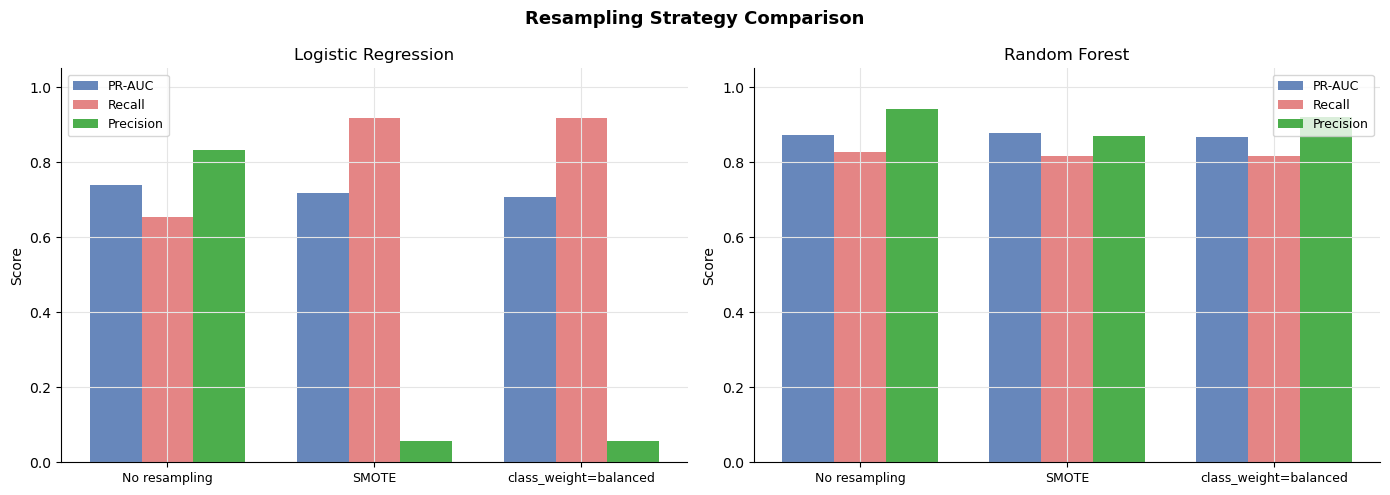

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Resampling Strategy Comparison", fontweight="bold", fontsize=13)
 
strategies = ["No resampling", "SMOTE", "class_weight=balanced"]
strat_colors = ["#aaaaaa", "#4C72B0", "#2ca02c"]
metrics = ["PR-AUC", "Recall", "Precision"]
 
for ax_idx, model_name in enumerate(["Logistic Regression", "Random Forest"]):
    ax  = axes[ax_idx]
    sub = results_df[results_df["Model"] == model_name]
    x   = np.arange(len(strategies))
    w   = 0.25
 
    for i, metric in enumerate(metrics):
        vals = [sub.loc[sub["Strategy"] == s, metric].values[0]
                for s in strategies]
        ax.bar(x + i * w, vals, w,
               label=metric,
               color=["#4C72B0", "#E07070", "#2ca02c"][i],
               alpha=0.85)
 
    ax.set_xticks(x + w)
    ax.set_xticklabels(strategies, fontsize=9)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{model_name}")
    ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase2_resampling_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### PRECISION-RECALL CURVES — ALL CONFIGURATIONS

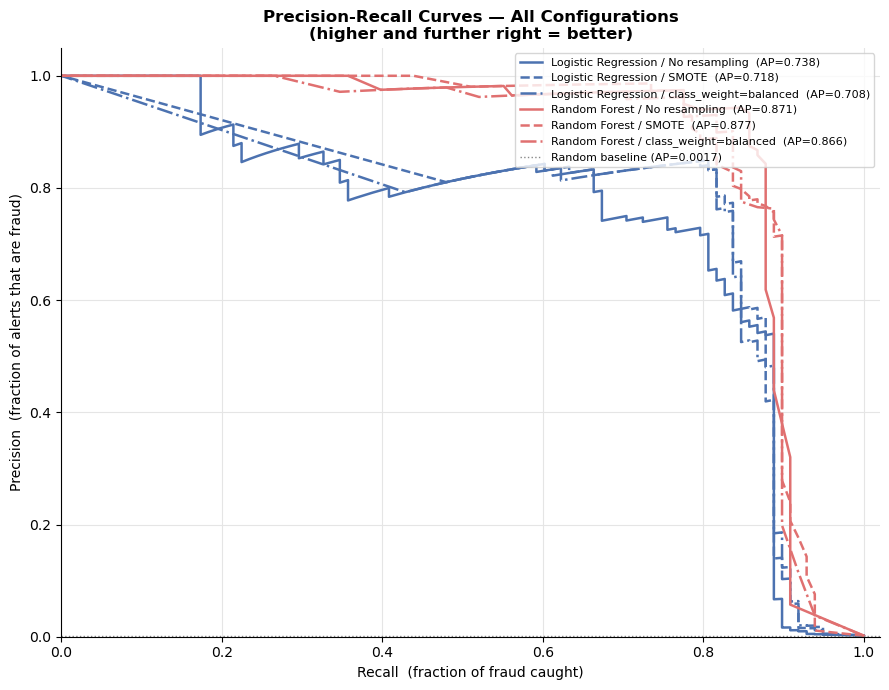

In [9]:
line_styles = {"No resampling": "-", "SMOTE": "--",
               "class_weight=balanced": "-."}
model_colors = {"Logistic Regression": "#4C72B0", "Random Forest": "#E07070"}
 
fig, ax = plt.subplots(figsize=(9, 7))
 
for key, (model, y_prob) in fitted_models.items():
    model_name, strategy = key.split(" | ")
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec_c, prec_c,
            color=model_colors[model_name],
            linestyle=line_styles[strategy],
            linewidth=1.8,
            label=f"{model_name} / {strategy}  (AP={ap:.3f})")
 
# Baseline: random classifier = fraud prevalence
baseline = y_test.mean()
ax.axhline(baseline, color="#888", linestyle=":", linewidth=1,
           label=f"Random baseline (AP={baseline:.4f})")
 
ax.set_xlabel("Recall  (fraction of fraud caught)")
ax.set_ylabel("Precision  (fraction of alerts that are fraud)")
ax.set_title("Precision-Recall Curves — All Configurations\n"
             "(higher and further right = better)", fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("phase2_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### BEST MODEL — CONFUSION MATRIX


Best model: Random Forest | SMOTE

Classification report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.87      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



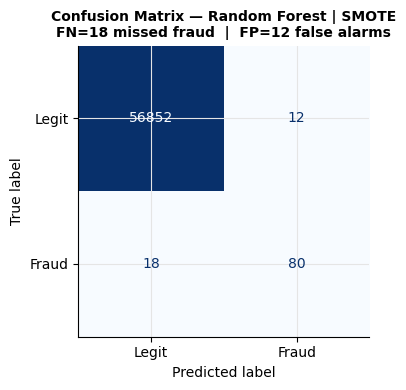

In [11]:
best_key   = results_df.iloc[0]["Model"] + " | " + results_df.iloc[0]["Strategy"]
best_model, best_prob = fitted_models[best_key]
best_pred  = best_model.predict(X_test)
 
print(f"\nBest model: {best_key}")
print(f"\nClassification report:")
print(classification_report(y_test, best_pred, target_names=["Legit", "Fraud"]))
 
fig, ax = plt.subplots(figsize=(5, 4))
cm   = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
fn = cm[1, 0]
fp = cm[0, 1]
ax.set_title(f"Confusion Matrix — {best_key}\n"
             f"FN={fn} missed fraud  |  FP={fp} false alarms",
             fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig("phase2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### THRESHOLD TUNING — BEST MODEL


Threshold tuning — Random Forest | SMOTE:
 Threshold  Precision  Recall    F1  FN  FP
      0.05      0.108   0.929 0.193   7 755
      0.10      0.278   0.898 0.425  10 228
      0.15      0.481   0.898 0.626  10  95
      0.20      0.587   0.898 0.710  10  62
      0.25      0.693   0.898 0.782  10  39
      0.30      0.737   0.888 0.806  11  31
      0.35      0.773   0.867 0.817  13  25
      0.40      0.785   0.857 0.820  14  23
      0.45      0.835   0.827 0.831  17  16
      0.50      0.860   0.816 0.838  18  13
      0.55      0.889   0.816 0.851  18  10
      0.60      0.897   0.796 0.843  20   9
      0.65      0.917   0.786 0.846  21   7
      0.70      0.917   0.786 0.846  21   7
      0.75      0.938   0.776 0.849  22   5
      0.80      0.962   0.776 0.859  22   3
      0.85      0.973   0.735 0.837  26   2
      0.90      0.984   0.633 0.770  36   1
      0.95      0.982   0.551 0.706  44   1

Best F1 at threshold : 0.80  (F1=0.8588  FN=22  FP=3)
Recall ≥ 90% at      :

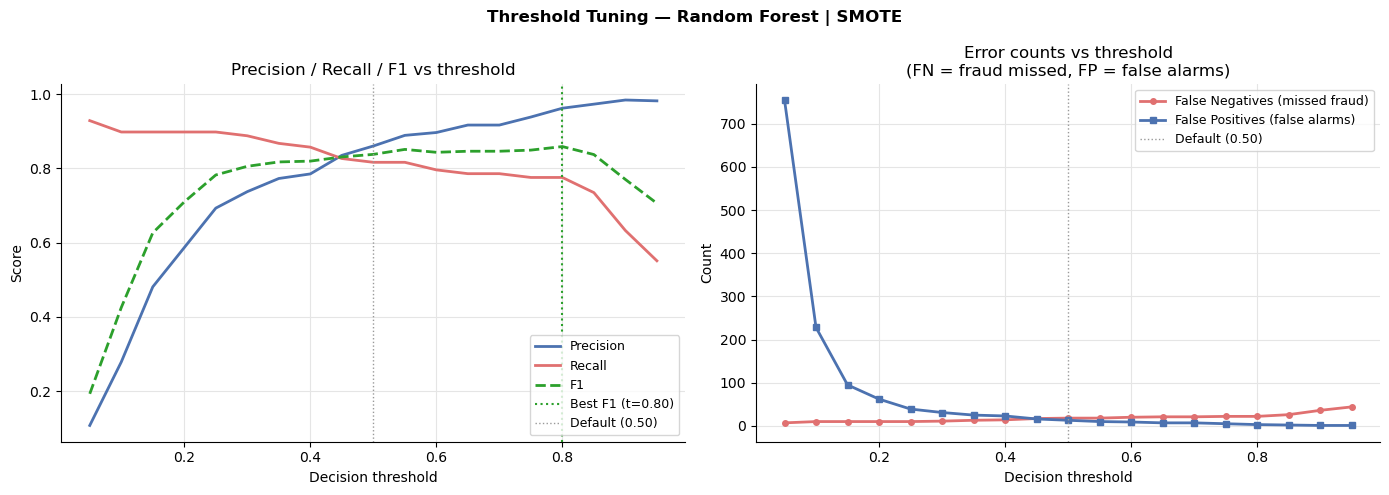

In [12]:
thresh_range = np.arange(0.05, 0.96, 0.05)
thresh_results = []
 
for t in thresh_range:
    y_pred_t = (best_prob >= t).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    thresh_results.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall"   : recall_score(y_test, y_pred_t, zero_division=0),
        "F1"       : f1_score(y_test, y_pred_t, zero_division=0),
        "FN"       : fn,
        "FP"       : fp,
    })
 
thresh_df    = pd.DataFrame(thresh_results)
best_f1_idx  = thresh_df["F1"].idxmax()
best_rec_idx = (thresh_df["Recall"] >= 0.90).idxmax()
 
print(f"\nThreshold tuning — {best_key}:")
print(thresh_df.round(3).to_string(index=False))
print(f"\nBest F1 at threshold : {thresh_df.loc[best_f1_idx,'Threshold']:.2f}  "
      f"(F1={thresh_df.loc[best_f1_idx,'F1']:.4f}  "
      f"FN={thresh_df.loc[best_f1_idx,'FN']}  "
      f"FP={thresh_df.loc[best_f1_idx,'FP']})")
print(f"Recall ≥ 90% at      : threshold={thresh_df.loc[best_rec_idx,'Threshold']:.2f}  "
      f"FN={thresh_df.loc[best_rec_idx,'FN']}  "
      f"FP={thresh_df.loc[best_rec_idx,'FP']}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Threshold Tuning — {best_key}", fontweight="bold")
 
ax = axes[0]
ax.plot(thresh_df["Threshold"], thresh_df["Precision"],
        color="#4C72B0", linewidth=2, label="Precision")
ax.plot(thresh_df["Threshold"], thresh_df["Recall"],
        color="#E07070", linewidth=2, label="Recall")
ax.plot(thresh_df["Threshold"], thresh_df["F1"],
        color="#2ca02c", linewidth=2, linestyle="--", label="F1")
ax.axvline(thresh_df.loc[best_f1_idx, "Threshold"],
           color="#2ca02c", linestyle=":", linewidth=1.5,
           label=f"Best F1 (t={thresh_df.loc[best_f1_idx,'Threshold']:.2f})")
ax.axvline(0.5, color="#999", linestyle=":", linewidth=1, label="Default (0.50)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs threshold")
ax.legend(fontsize=9)
 
ax2 = axes[1]
ax2.plot(thresh_df["Threshold"], thresh_df["FN"],
         color="#E07070", linewidth=2, marker="o",
         markersize=4, label="False Negatives (missed fraud)")
ax2.plot(thresh_df["Threshold"], thresh_df["FP"],
         color="#4C72B0", linewidth=2, marker="s",
         markersize=4, label="False Positives (false alarms)")
ax2.axvline(0.5, color="#999", linestyle=":", linewidth=1, label="Default (0.50)")
ax2.set_xlabel("Decision threshold")
ax2.set_ylabel("Count")
ax2.set_title("Error counts vs threshold\n(FN = fraud missed, FP = false alarms)")
ax2.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase2_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
pred_df = pd.DataFrame({
    "y_true"          : y_test.values,
    "supervised_prob" : best_prob,
    "supervised_pred" : best_pred,
})
pred_df.to_csv("fraud_supervised_predictions.csv", index=False)
print(f"\nSaved: fraud_supervised_predictions.csv  ← used in Phase 4 comparison")


Saved: fraud_supervised_predictions.csv  ← used in Phase 4 comparison
